# Exploratory data analysis: January 2025 feasibility sample

This notebook describes the processed PJM PSEG and NYISO Hudson Valley hourly data. January 2025 is a feasibility sample only; it is not the final model-training period.

Before exploratory analysis, verify that each market table has one complete, unique hourly record for every hour in January.

In [1]:
# Purpose: it loads the two processed January tables into market_data.
# This is like a C# Dictionary<string, DataFrame> or two SQL tables
# stored under descriptive names.


import pandas as pd
from IPython.display import display

from electricity_forecasting.config import PROCESSED_DATA_DIR

MARKET_FILES = {
    "PJM PSEG": PROCESSED_DATA_DIR / "pjm_pseg_january_2025_electricity.csv",
    "NYISO Hudson Valley": (
        PROCESSED_DATA_DIR / "nyiso_hudson_valley_january_2025_electricity.csv"
    ),
}

market_data = {
    market: pd.read_csv(
        file_path,
        parse_dates=["timestamp_local", "timestamp_utc"],
    )
    for market, file_path in MARKET_FILES.items()
}

for market, data in market_data.items():
    print(f"{market}: {data.shape[0]} rows, {data.shape[1]} columns")

PJM PSEG: 744 rows, 26 columns
NYISO Hudson Valley: 744 rows, 26 columns


In [2]:
REQUIRED_COLUMNS = {
    "timestamp_local",
    "timestamp_utc",
    "day_ahead_price_usd_mwh",
    "actual_load_mw",
}

for market, data in market_data.items():
    missing_columns = REQUIRED_COLUMNS - set(data.columns)

    assert not missing_columns, (
        f"{market} is missing required columns: {sorted(missing_columns)}"
    )
    assert len(data) == 744, f"{market} should have 744 January hours."
    assert data["timestamp_utc"].is_unique, (
        f"{market} has duplicate UTC timestamps."
    )
    assert data["timestamp_utc"].is_monotonic_increasing, (
        f"{market} is not ordered chronologically."
    )
    assert data["day_ahead_price_usd_mwh"].notna().all(), (
        f"{market} has missing day-ahead prices."
    )
    assert data["actual_load_mw"].notna().all(), (
        f"{market} has missing actual-load values."
    )

print("All January 2025 feasibility-table checks passed.")

All January 2025 feasibility-table checks passed.


In [3]:
# summarize the target price distribution in each market. 
# This is descriptive only—no predictors, no models, and 
# no removal of negative or high prices.

# agg(...) calculates several summaries from one price column.
# The dictionary comprehension is like a C# ToDictionary() over the 
# two market tables.
# .T transposes the result so each market is one row, like turning 
# SQL aggregate columns into a comparison table.
# std measures variability; min and max reveal negative prices 
# and spikes without deleting them.
#Expected: a two-row table—PJM PSEG and NYISO Hudson
#  Valley—with count = 744 for both and columns mean, 
# std, min, median, and max.


price_summary = pd.DataFrame(
    {
        market: data["day_ahead_price_usd_mwh"].agg(
            ["count", "mean", "std", "min", "median", "max"]
        )
        for market, data in market_data.items()
    }
).T

price_summary.round(2)

,count,mean,std,min,median,max
PJM PSEG,744.0,66.99,55.76,20.64,46.71,319.87
NYISO Hudson Valley,744.0,122.52,55.78,28.22,113.79,338.56


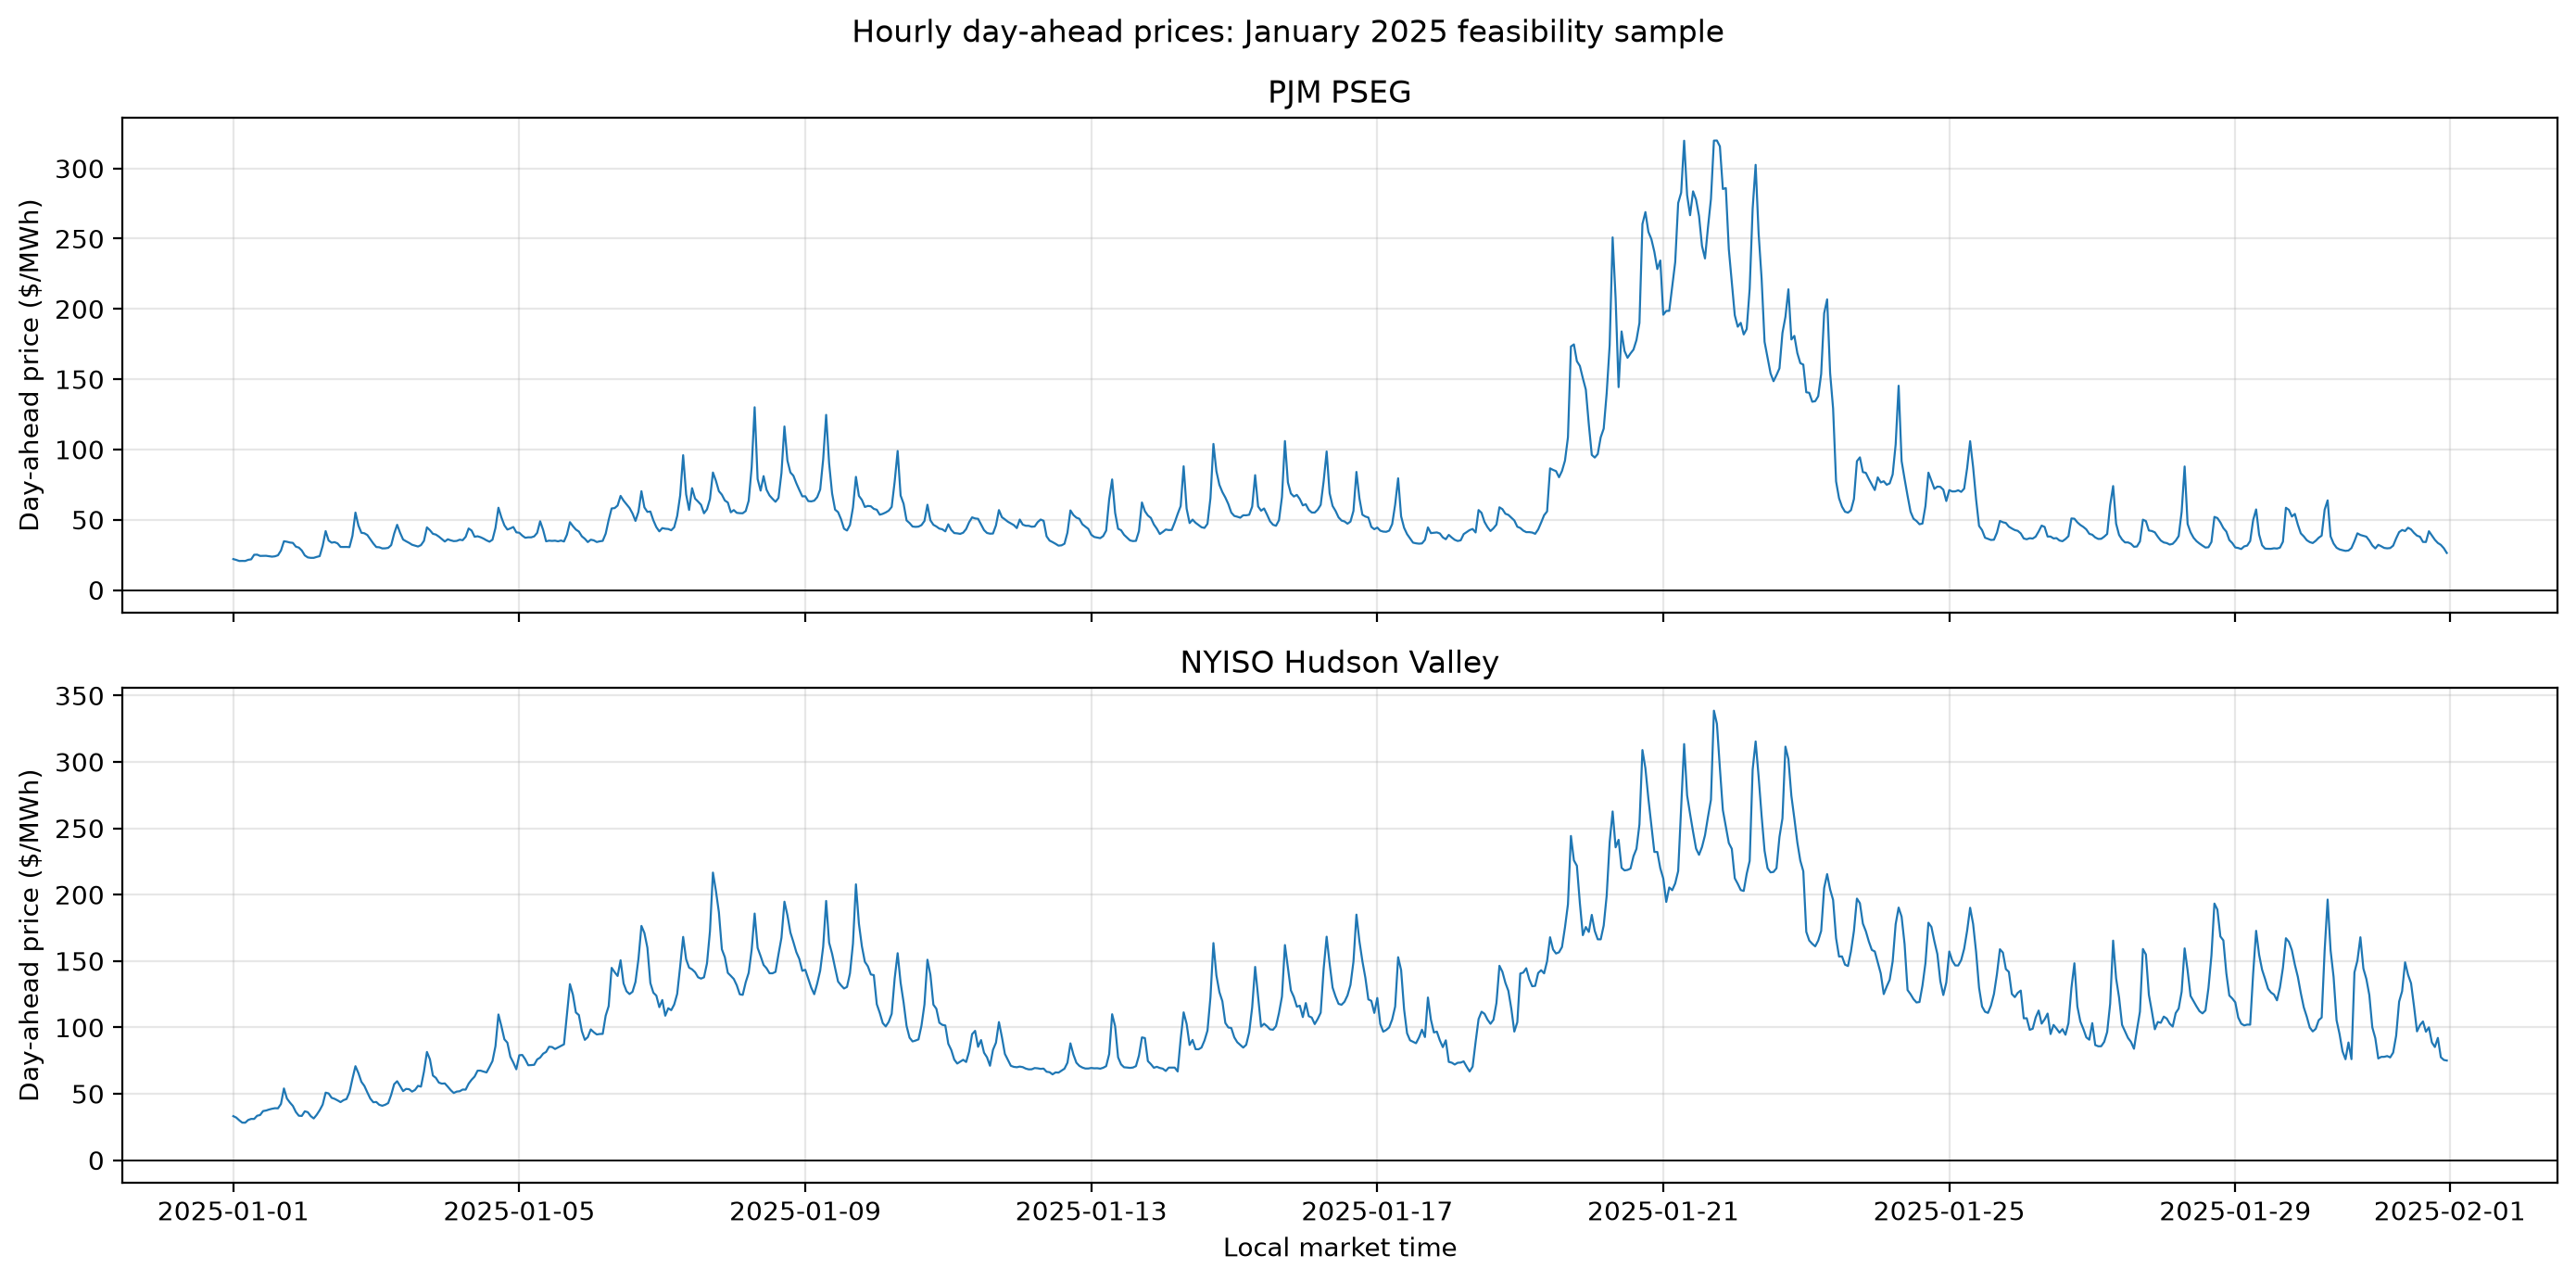

In [4]:
# What it shows, descriptively:
# Both markets have a concentrated high-price period around January 20–22.
# PJM’s spike is sharper and drops quickly afterward.
# NYISO stays at a higher level for more of the month, including an 
# earlier elevated period around January 6–10.
# Neither series drops below the zero line in this January sample.
# These are observed patterns, not proof of causes. We will not claim weather
# or load caused them without a carefully limited descriptive analysis.

import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(14, 7),
    sharex=True,
)

for axis, (market, data) in zip(
    axes,
    market_data.items(),
    strict=True,
):
    axis.plot(
        data["timestamp_local"],
        data["day_ahead_price_usd_mwh"],
        linewidth=0.8,
    )
    axis.axhline(0, color="black", linewidth=0.7)
    axis.set_title(market)
    axis.set_ylabel("Day-ahead price ($/MWh)")
    axis.grid(alpha=0.3)

axes[-1].set_xlabel("Local market time")
fig.suptitle("Hourly day-ahead prices: January 2025 feasibility sample")
fig.tight_layout()
plt.show()

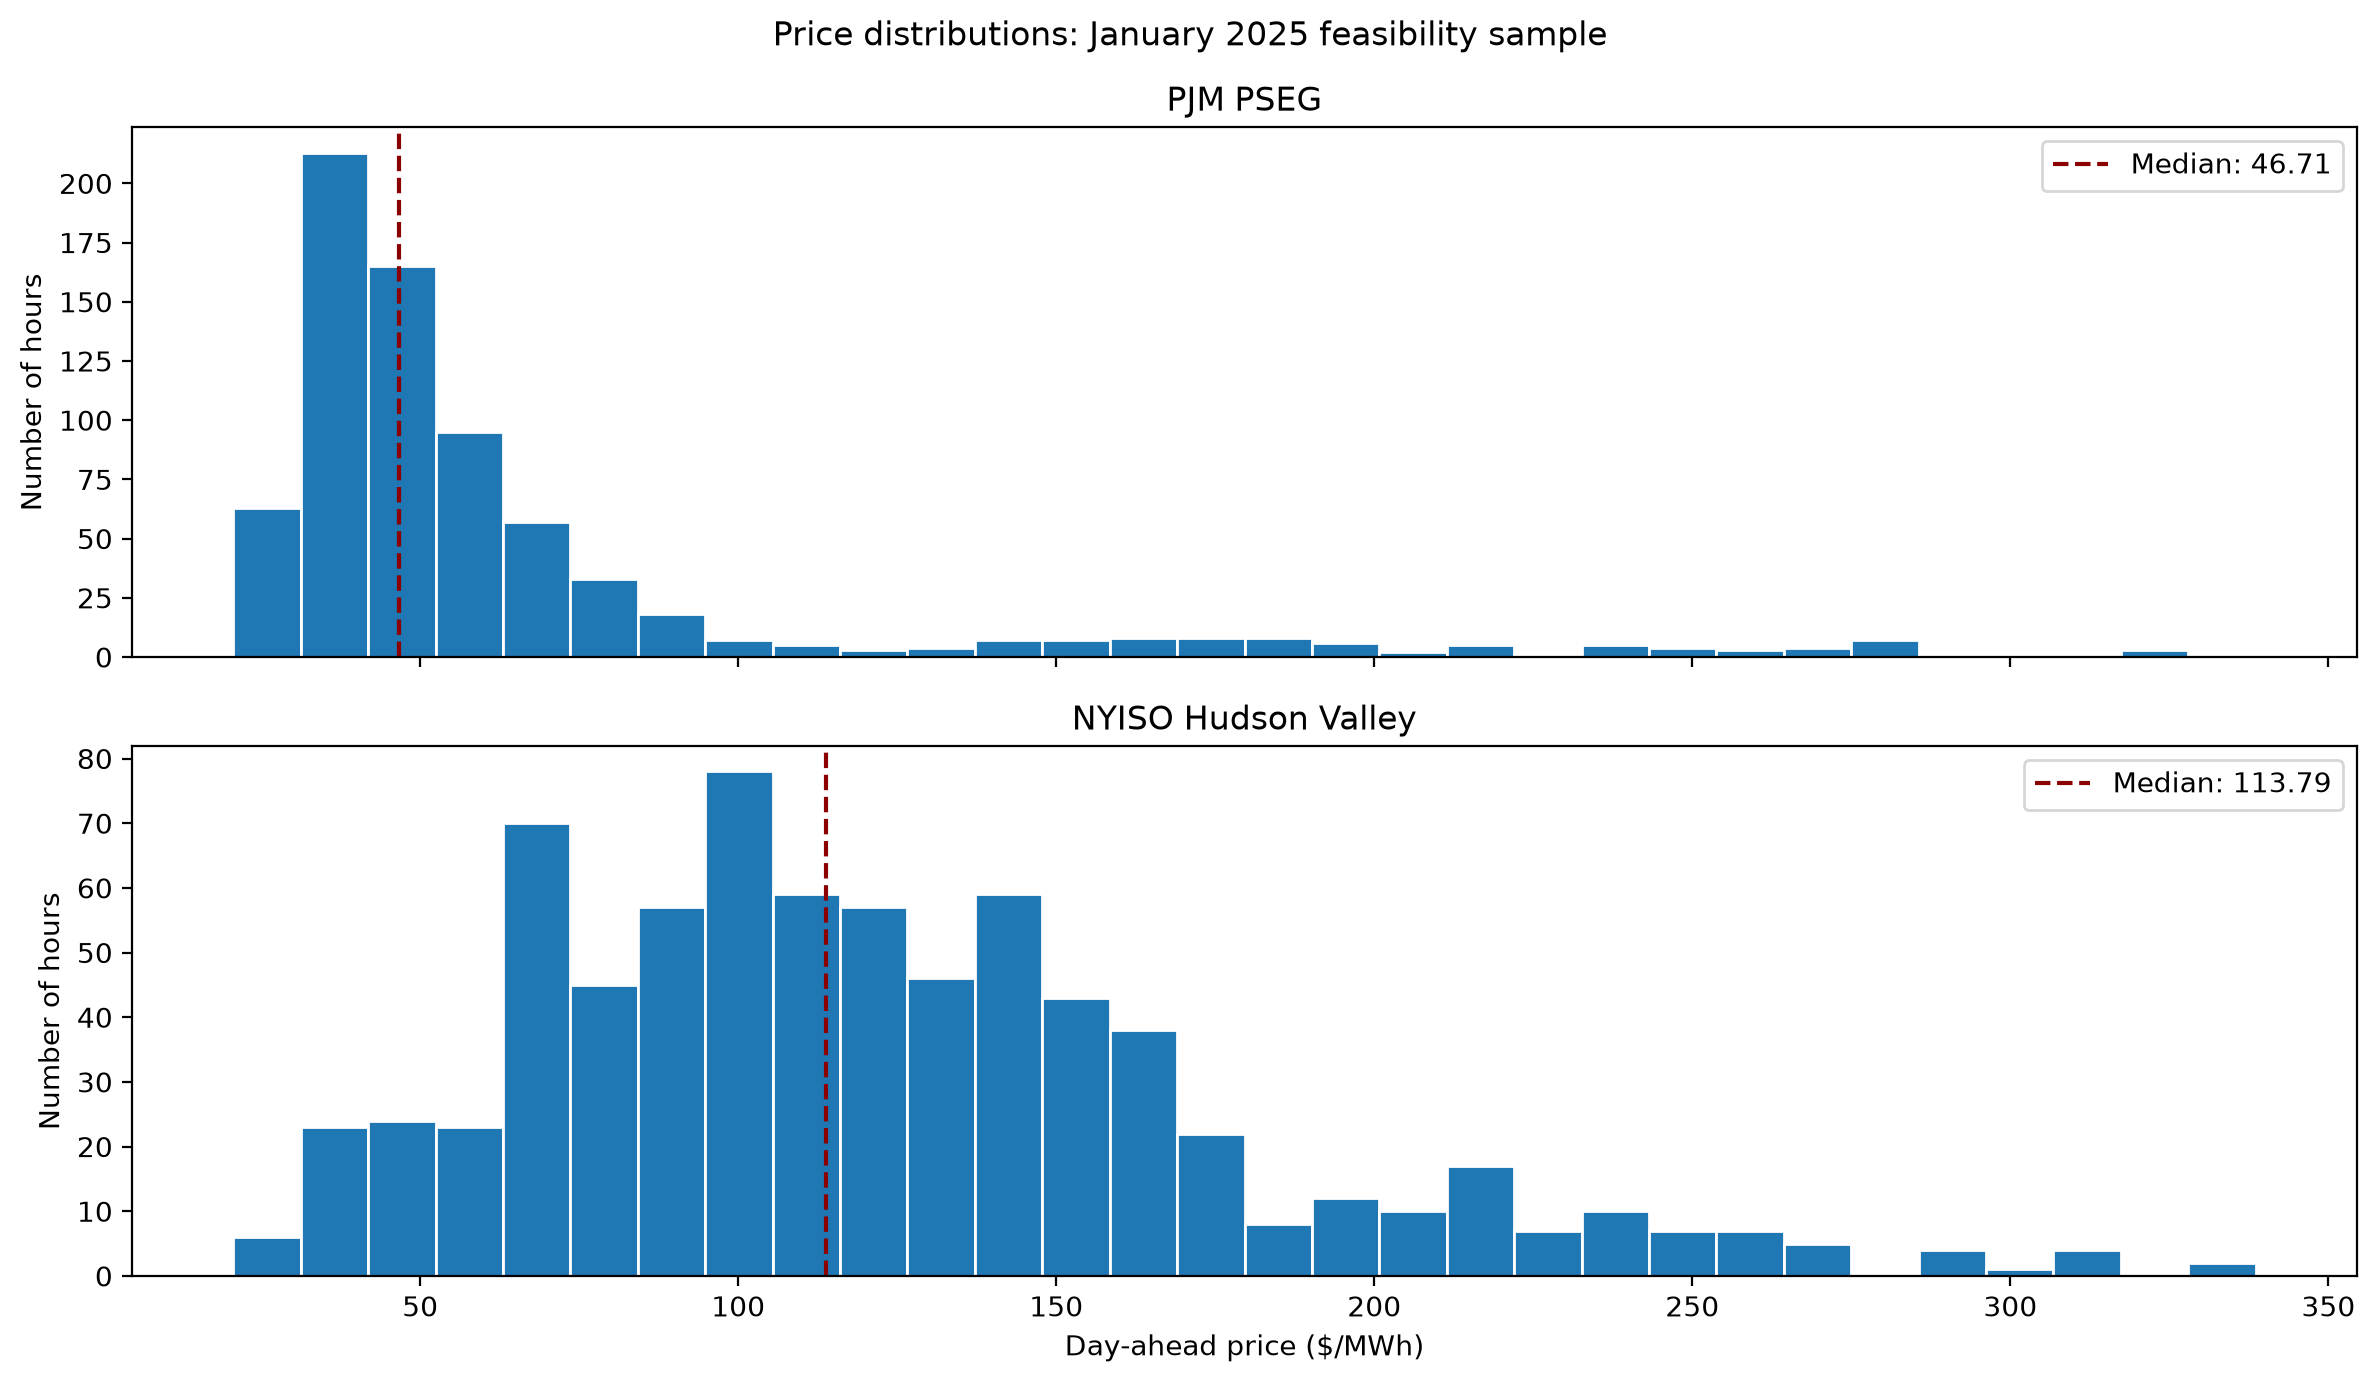

In [5]:
# : pd.concat(...) is like SQL UNION ALL for the two price columns. 
# The shared bin_edges ensure a bar at, for example, $100–$110/MWh means 
# the same thing in both panels.

#PJM: strongly right-skewed. Most hours are roughly in the $35–$80/MWh range,
# with a long, sparse tail of spike hours.
# NYISO: centered much higher and spread across a broader midrange, 
# while still having a right tail of high-price hours.
# In both, the mean exceeds the median because high-price hours pull
# the average upward.

import numpy as np

all_prices = pd.concat(
    [
        data["day_ahead_price_usd_mwh"]
        for data in market_data.values()
    ],
    ignore_index=True,
)

bin_edges = np.linspace(
    all_prices.min(),
    all_prices.max(),
    31,
)

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 7),
    sharex=True,
)

for axis, (market, data) in zip(
    axes,
    market_data.items(),
    strict=True,
):
    prices = data["day_ahead_price_usd_mwh"]

    axis.hist(
        prices,
        bins=bin_edges,
        edgecolor="white",
    )
    axis.axvline(
        prices.median(),
        color="darkred",
        linestyle="--",
        label=f"Median: {prices.median():.2f}",
    )
    axis.set_title(market)
    axis.set_ylabel("Number of hours")
    axis.legend()

axes[-1].set_xlabel("Day-ahead price ($/MWh)")
fig.suptitle("Price distributions: January 2025 feasibility sample")
fig.tight_layout()
plt.show()

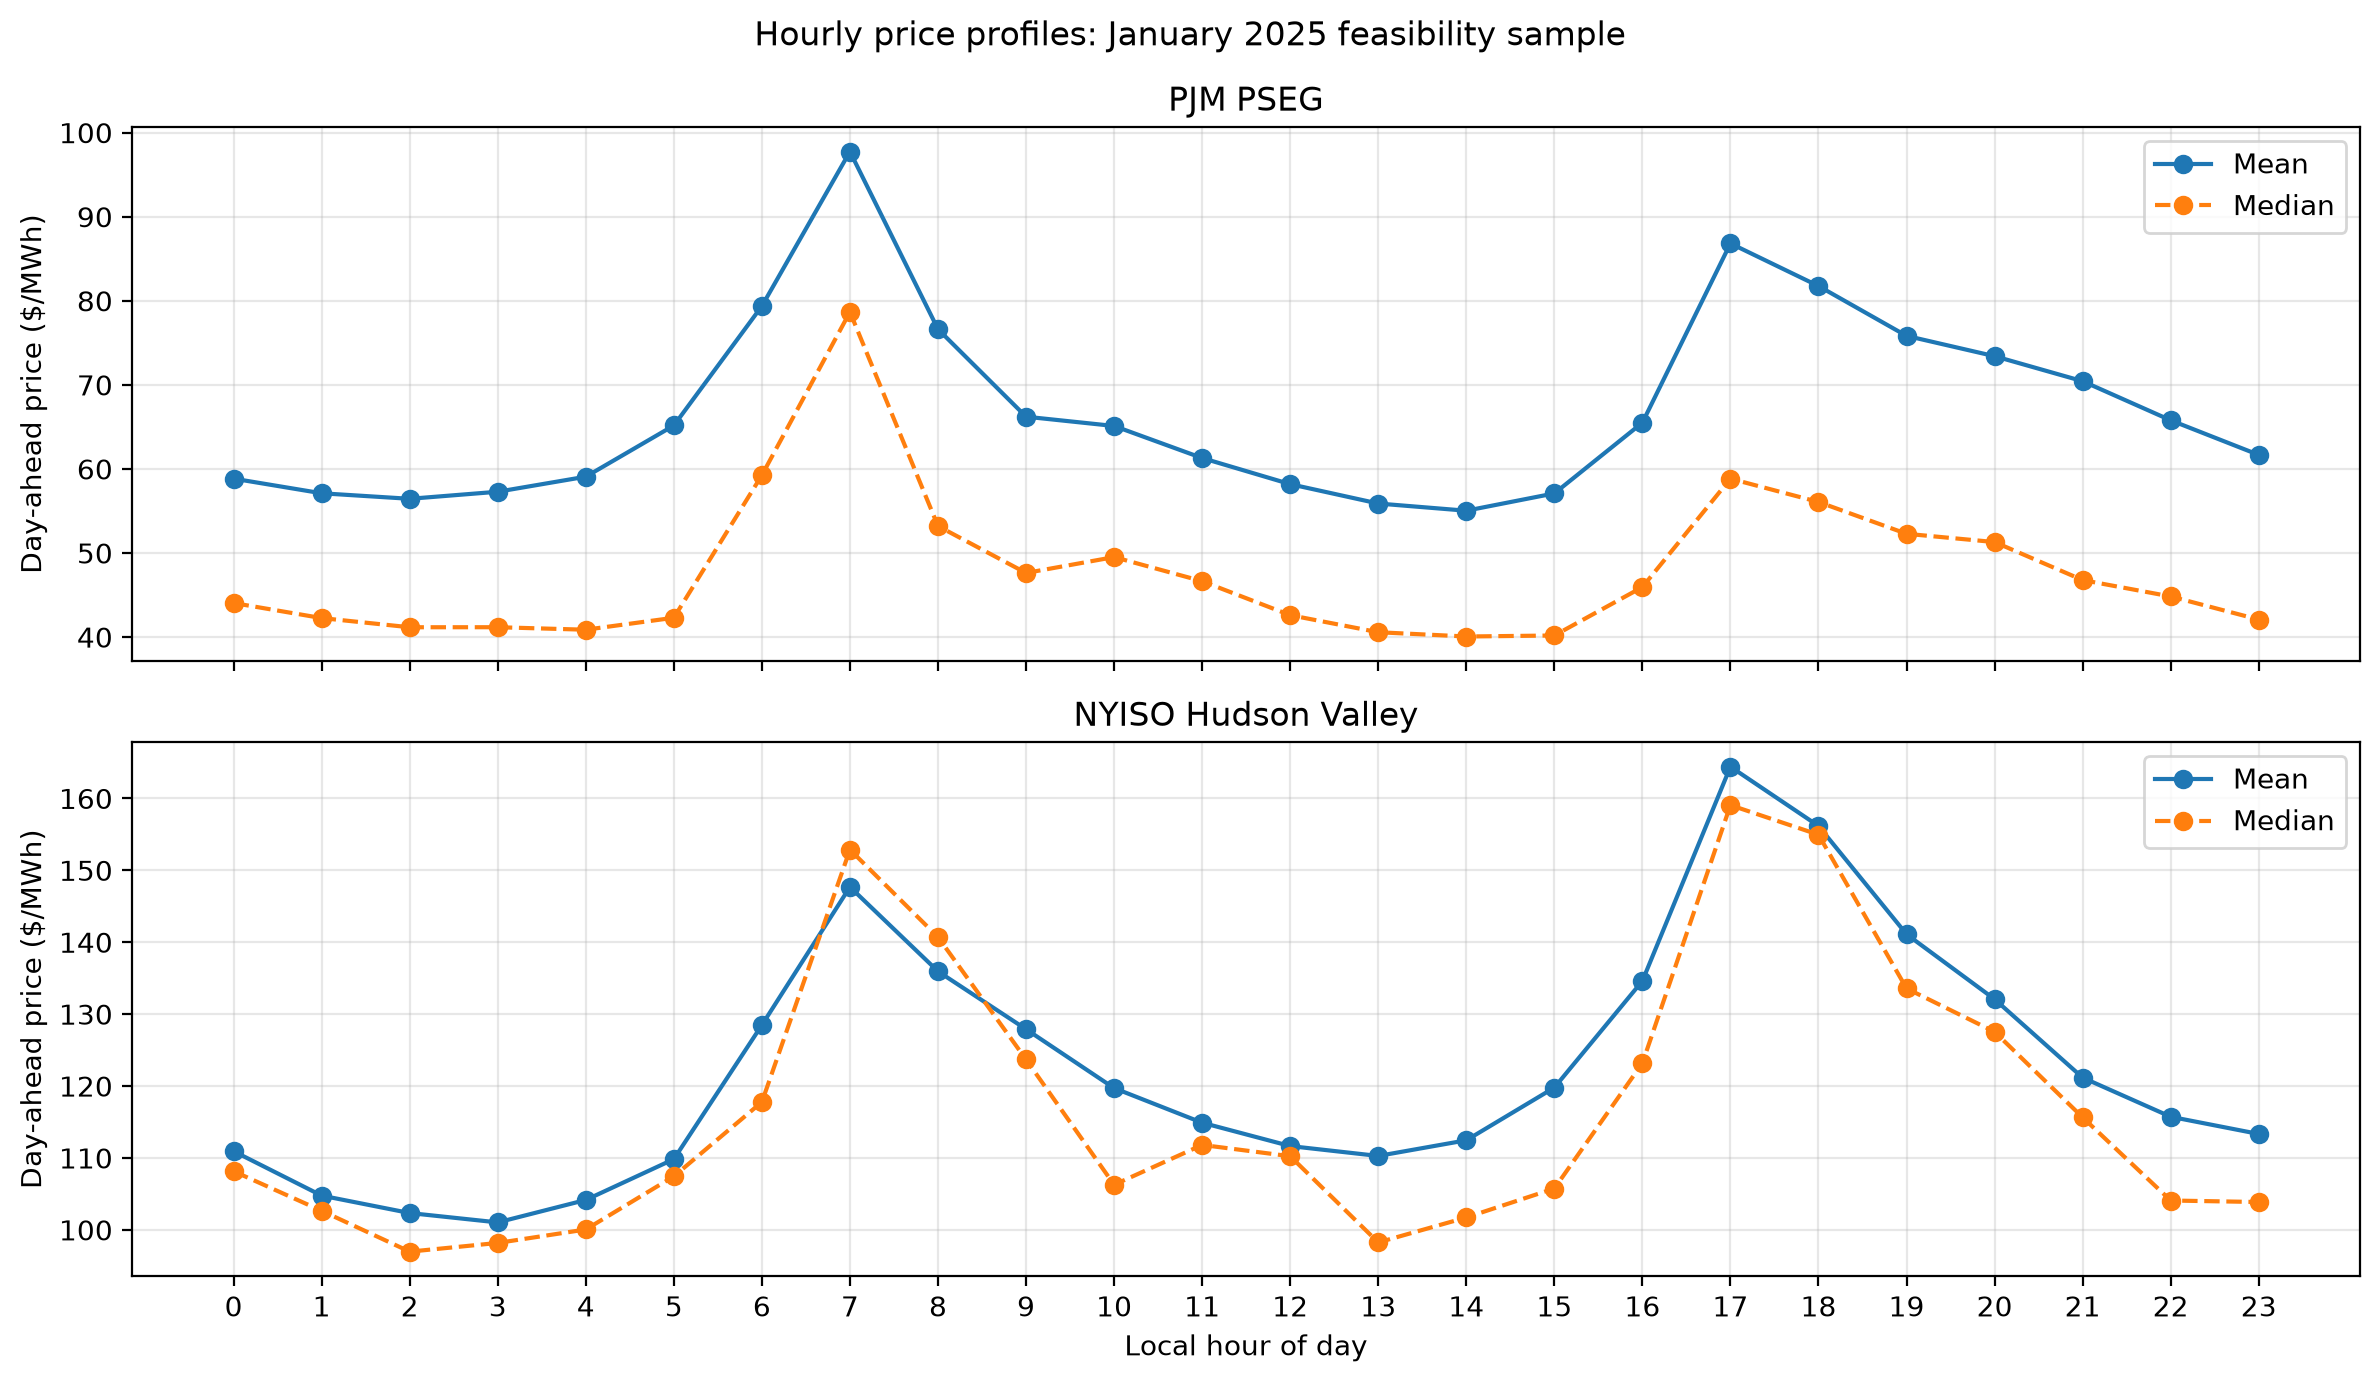

In [6]:
# examine the daily intraday pattern: how typical price changes by 
# local hour of day. This is useful because electricity prices often 
# follow a daily operating cycle, but it does not say anything causal.
# The median line shows the typical hour without being pulled as much 
# by spikes; the mean line shows the average including those spikes.


# PJM: prices rise into a strong morning peak around hour 7 and a second 
# evening peak around hour 17. The mean sits well above the median at 
# those peaks, so occasional spikes are inflating the average.
# NYISO: prices are higher at every hour, with a morning rise near hour 
# 7 and the strongest peak around hour 17. Mean and median are closer, 
# although spike effects still appear.
# This supports using both mean and median in EDA. The median better
# represents a typical hour; the mean reflects the effect of spikes.

hourly_price_profiles = {}

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 7),
    sharex=True,
)

for axis, (market, data) in zip(
    axes,
    market_data.items(),
    strict=True,
):
    profile = (
        data.assign(
            hour_of_day=data["timestamp_local"].dt.hour
        )
        .groupby("hour_of_day")["day_ahead_price_usd_mwh"]
        .agg(["mean", "median"])
        .reindex(range(24))
    )

    hourly_price_profiles[market] = profile

    axis.plot(
        profile.index,
        profile["mean"],
        marker="o",
        label="Mean",
    )
    axis.plot(
        profile.index,
        profile["median"],
        marker="o",
        linestyle="--",
        label="Median",
    )
    axis.set_title(market)
    axis.set_ylabel("Day-ahead price ($/MWh)")
    axis.grid(alpha=0.3)
    axis.legend()

axes[-1].set_xlabel("Local hour of day")
axes[-1].set_xticks(range(24))
fig.suptitle("Hourly price profiles: January 2025 feasibility sample")
fig.tight_layout()
plt.show()

In [7]:
# Both markets had lower average and median prices on weekends in this sample.
# Weekday prices also had higher variability, especially in PJM. This is
# descriptive evidence of a weekday/weekend pattern, not a forecast result.

day_type_price_summary = pd.concat(
    {
        market: (
            data.assign(
                day_type=np.where(
                    data["timestamp_local"].dt.dayofweek >= 5,
                    "Weekend",
                    "Weekday",
                )
            )
            .groupby("day_type")["day_ahead_price_usd_mwh"]
            .agg(["count", "mean", "median", "std", "min", "max"])
        )
        for market, data in market_data.items()
    },
    names=["market", "day_type"],
)

day_type_price_summary.round(2)

count    mean  median    std    min     max
market              day_type                                             
PJM PSEG            Weekday     552   72.84   51.24  62.07  20.64  319.87
                    Weekend     192   50.17   43.26  24.46  31.56  174.76
NYISO Hudson Valley Weekday     552  129.35  122.82  59.42  28.22  338.56
                    Weekend     192  102.89   92.71  37.40  50.61  244.20

,pearson_correlation
PJM PSEG,0.579
NYISO Hudson Valley,0.713


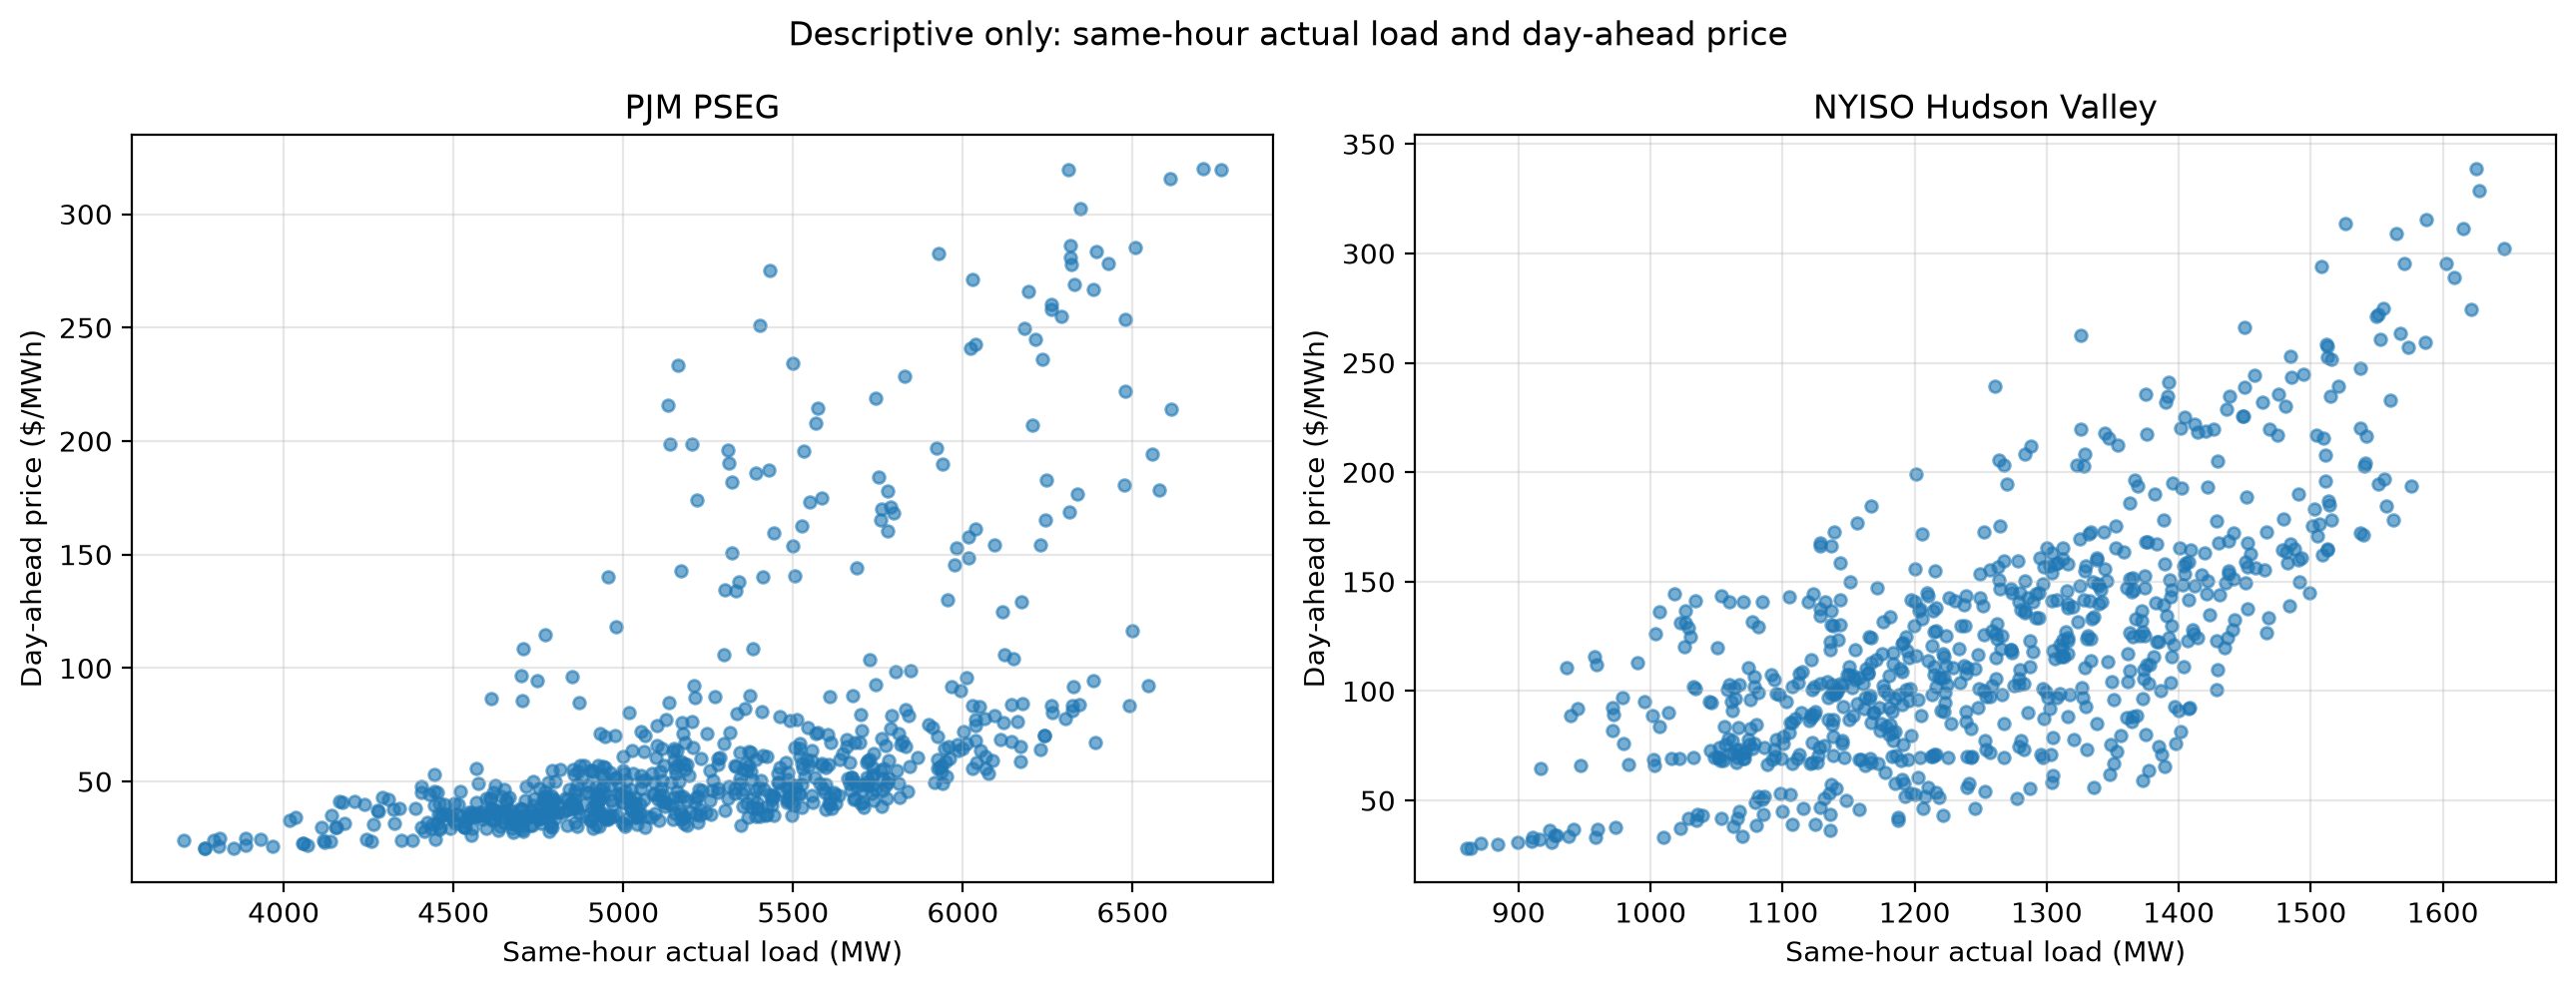

In [8]:
# .corr(...) calculates Pearson correlation, a number from −1 to +1
#  describing linear association. The scatterplot lets us see whether that 
# single number hides clusters or spikes.
# Important limitation: same-hour actual load is known after the day-ahead 
# prediction cutoff. We may describe this relationship, but we must not use
# actual_load_mw as an operational predictor.

load_price_correlation = pd.DataFrame(
    {
        "pearson_correlation": {
            market: data["actual_load_mw"].corr(
                data["day_ahead_price_usd_mwh"]
            )
            for market, data in market_data.items()
        }
    }
)

display(load_price_correlation.round(3))

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(13, 5),
)

for axis, (market, data) in zip(
    axes,
    market_data.items(),
    strict=True,
):
    axis.scatter(
        data["actual_load_mw"],
        data["day_ahead_price_usd_mwh"],
        alpha=0.6,
        s=18,
    )
    axis.set_title(market)
    axis.set_xlabel("Same-hour actual load (MW)")
    axis.set_ylabel("Day-ahead price ($/MWh)")
    axis.grid(alpha=0.3)

fig.suptitle(
    "Descriptive only: same-hour actual load and day-ahead price"
)
fig.tight_layout()
plt.show()

In [9]:
weather_audit_summary = pd.DataFrame(
    {
        market: data[
            [
                "weather_quality_flagged",
                "weather_value_rejected",
                "weather_missing",
                "weather_imputed",
            ]
        ]
        .sum()
        .astype("int64")
        for market, data in market_data.items()
    }
).T

weather_audit_summary

,weather_quality_flagged,weather_value_rejected,weather_missing,weather_imputed
PJM PSEG,0,0,3,0
NYISO Hudson Valley,7,4,7,0


,nonmissing_hours,pearson_correlation
PJM PSEG,741,-0.685
NYISO Hudson Valley,737,-0.678


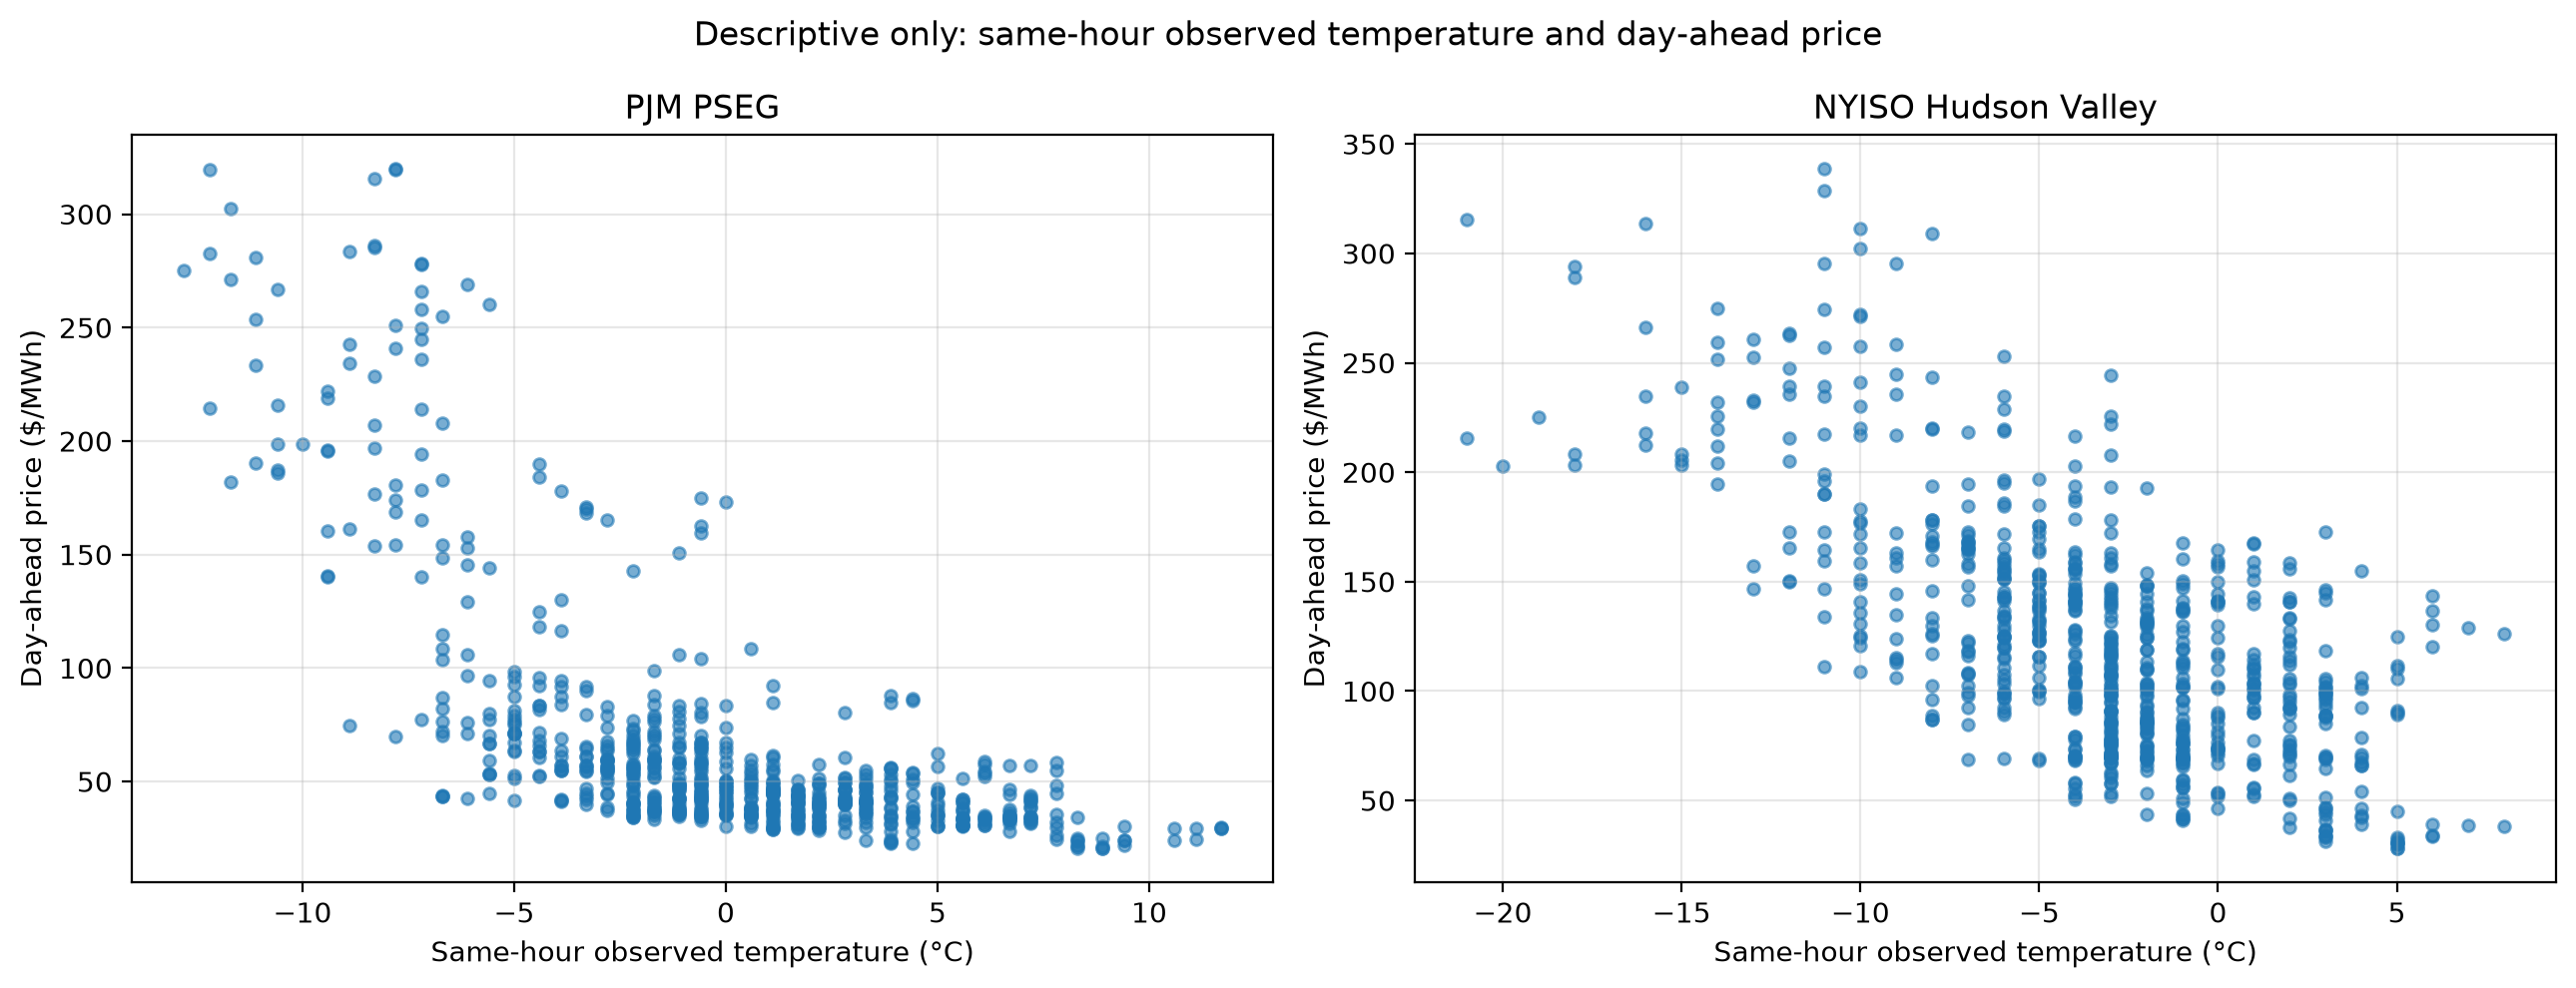

In [10]:
temperature_price_summary = {}

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(13, 5),
)

for axis, (market, data) in zip(
    axes,
    market_data.items(),
    strict=True,
):
    descriptive_data = data.dropna(
        subset=[
            "temperature_c",
            "day_ahead_price_usd_mwh",
        ]
    )

    correlation = descriptive_data["temperature_c"].corr(
        descriptive_data["day_ahead_price_usd_mwh"]
    )

    temperature_price_summary[market] = {
        "nonmissing_hours": len(descriptive_data),
        "pearson_correlation": correlation,
    }

    axis.scatter(
        descriptive_data["temperature_c"],
        descriptive_data["day_ahead_price_usd_mwh"],
        alpha=0.6,
        s=18,
    )
    axis.set_title(market)
    axis.set_xlabel("Same-hour observed temperature (°C)")
    axis.set_ylabel("Day-ahead price ($/MWh)")
    axis.grid(alpha=0.3)

display(
    pd.DataFrame.from_dict(
        temperature_price_summary,
        orient="index",
    ).round(3)
)

fig.suptitle(
    "Descriptive only: same-hour observed temperature and day-ahead price"
)
fig.tight_layout()
plt.show()

In [11]:
# this is the pandas equivalent of inspecting a SQL table’s schema plus
#  MIN()/MAX() timestamp queries.
#  It proves the EDA is using the expected columns and timestamp coverage

for market, data in market_data.items():
    print(f"\n{market}")
    print(
        "Local timestamp range:",
        data["timestamp_local"].min(),
        "to",
        data["timestamp_local"].max(),
    )
    print(
        "UTC timestamp range:",
        data["timestamp_utc"].min(),
        "to",
        data["timestamp_utc"].max(),
    )

    display(
        pd.DataFrame(
            {
                "column": data.columns,
                "dtype": data.dtypes.astype(str).to_numpy(),
            }
        )
    )


PJM PSEG
Local timestamp range: 2025-01-01 00:00:00-05:00 to 2025-01-31 23:00:00-05:00
UTC timestamp range: 2025-01-01 05:00:00+00:00 to 2025-02-01 04:00:00+00:00


,column,dtype
0,timestamp_local,"datetime64[us, UTC-05:00]"
1,timestamp_utc,"datetime64[us, UTC]"
2,location_id,int64
3,location,str
4,day_ahead_price_usd_mwh,float64
5,energy_component_usd_mwh,float64
6,congestion_component_usd_mwh,float64
7,loss_component_usd_mwh,float64
8,zone,str
9,load_area,str



NYISO Hudson Valley
Local timestamp range: 2025-01-01 00:00:00-05:00 to 2025-01-31 23:00:00-05:00
UTC timestamp range: 2025-01-01 05:00:00+00:00 to 2025-02-01 04:00:00+00:00


,column,dtype
0,timestamp_local,"datetime64[us, UTC-05:00]"
1,timestamp_utc,"datetime64[us, UTC]"
2,location_id,int64
3,location,str
4,day_ahead_price_usd_mwh,float64
5,loss_component_usd_mwh,float64
6,congestion_component_usd_mwh,float64
7,energy_component_usd_mwh,float64
8,source_time_zone,str
9,load_location,str


In [12]:
# it uses the same transparent summary pattern as the price table, making the 
# two markets comparable. actual_load_mw is not a valid same-hour operational 
# predictor; here we use it only to describe the January feasibility data.

load_summary = pd.DataFrame(
    {
        market: data["actual_load_mw"].agg(
            ["count", "mean", "std", "min", "median", "max"]
        )
        for market, data in market_data.items()
    }
).T

load_summary.round(2)

,count,mean,std,min,median,max
PJM PSEG,744.0,5223.41,582.55,3706.24,5169.95,6760.71
NYISO Hudson Valley,744.0,1252.42,156.63,860.98,1248.39,1646.45


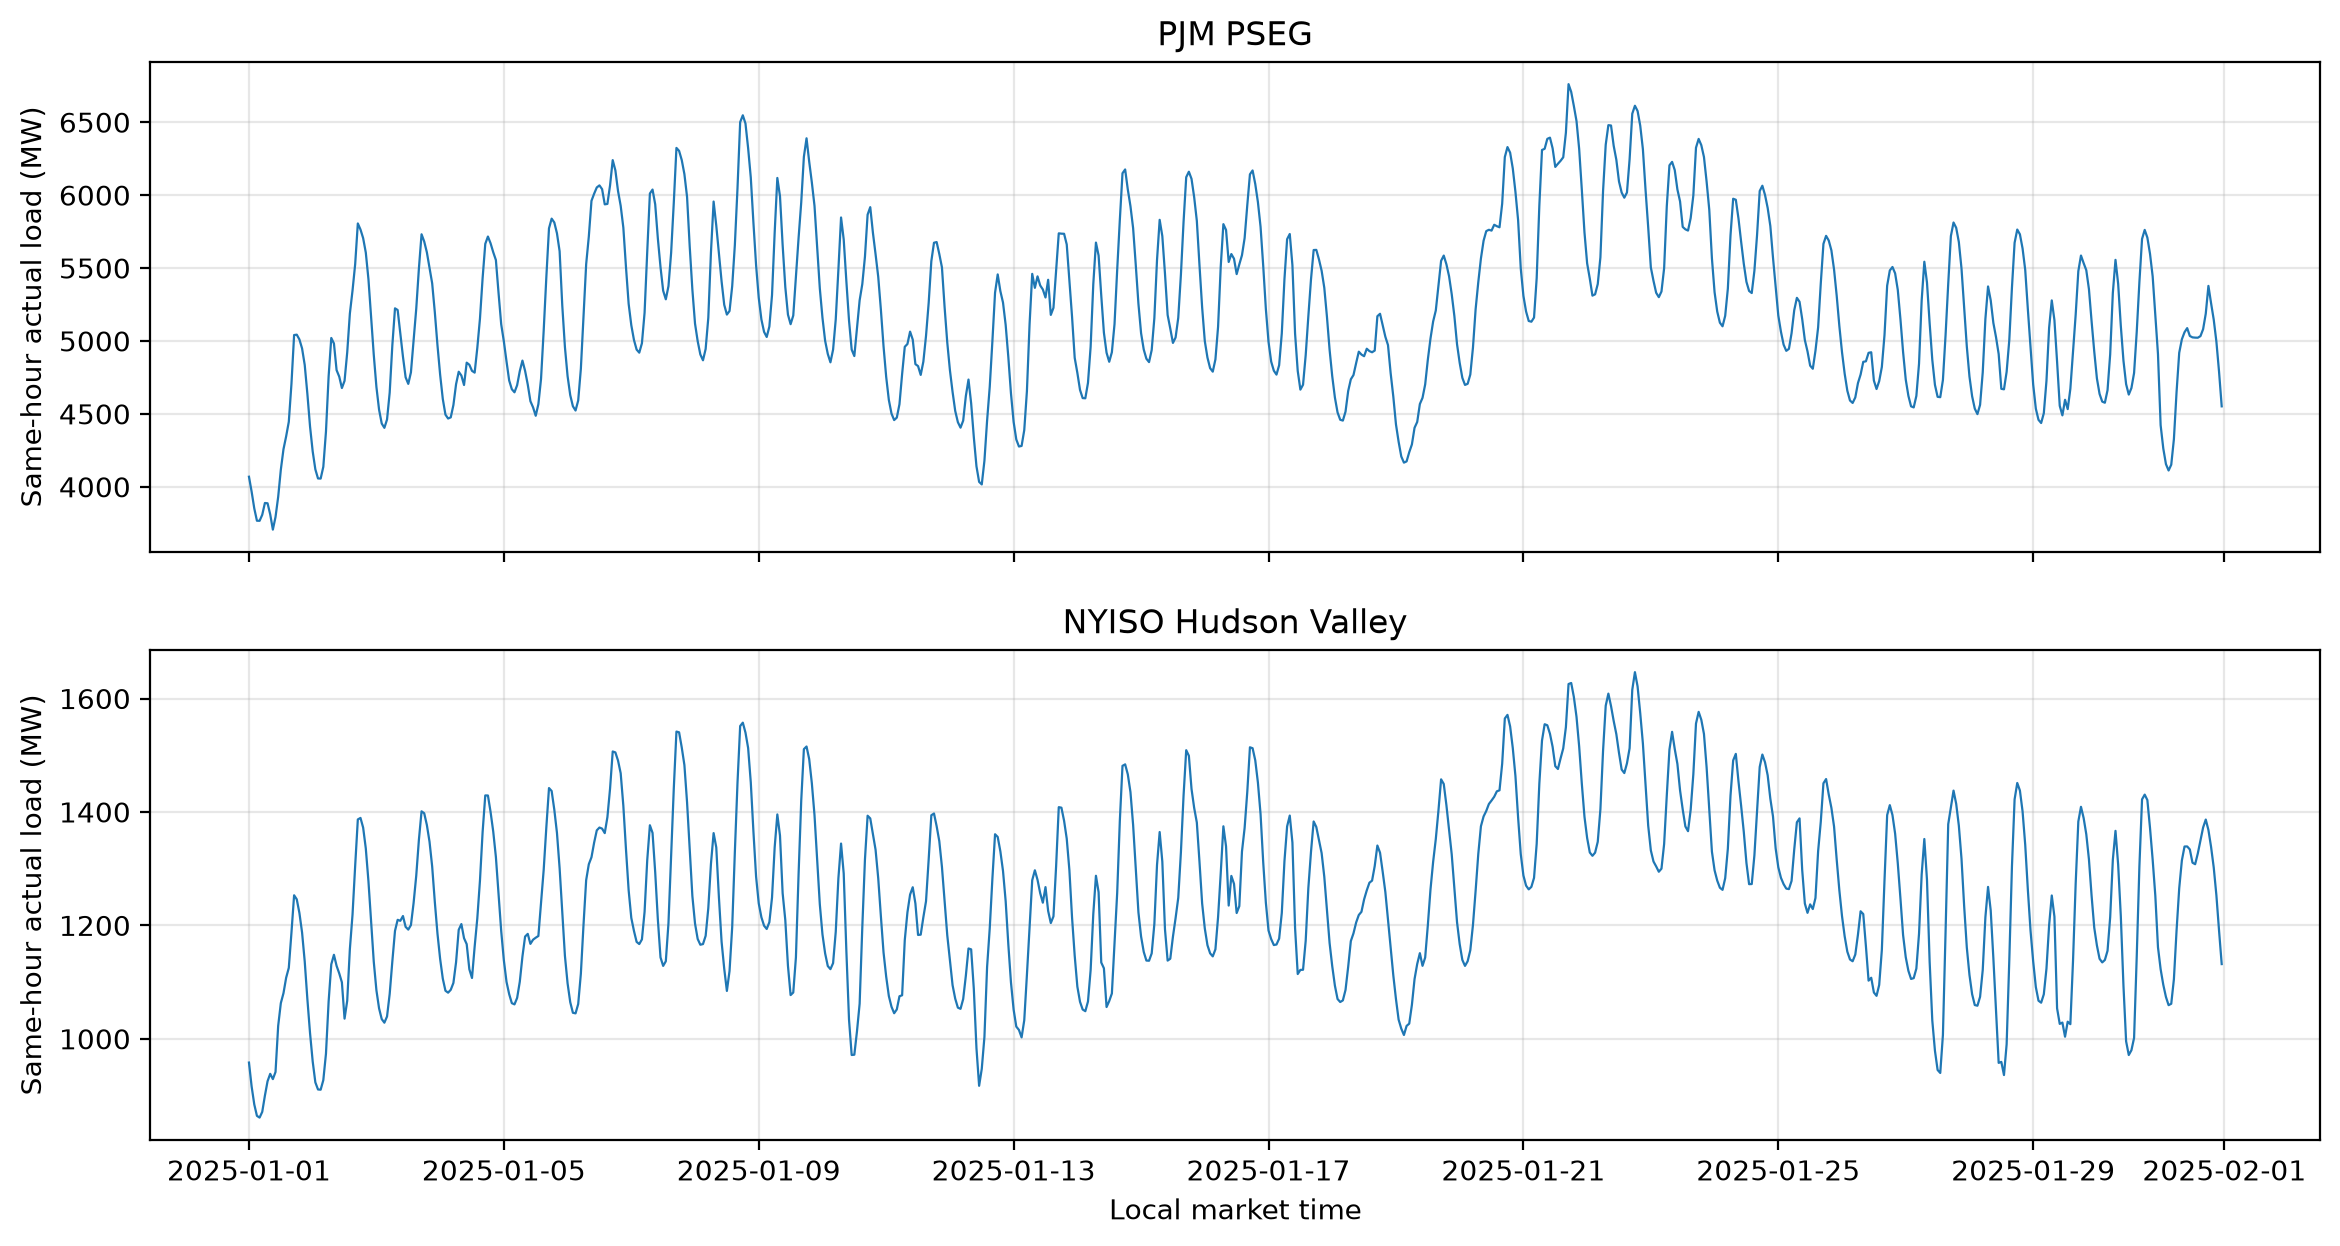

In [13]:
# this lets us see load’s daily cycle and any broader January changes.
#  It does not promote same-hour actual load into a day-ahead feature.
# The load charts show repeated daily cycles in both markets and higher 
# loads around January 20–23, which overlaps with the high-price period.
# That overlap is descriptive only; it does not prove load caused the prices.

ig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(14, 7),
    sharex=True,
)

for axis, (market, data) in zip(
    axes,
    market_data.items(),
    strict=True,
):
    axis.plot(
        data["timestamp_local"],
        data["actual_load_mw"],
        linewidth=0.8,
    )
    axis.set_title(market)
    axis.set_ylabel("Same-hour actual load (MW)")
    axis.grid(alpha=0.3)

axes[-1].set_xlabel("Local market time")
fig.suptitle(
    "Descriptive only: hourly actual load, January 2025 feasibility sample"
)
fig.tight_layout()
plt.show()

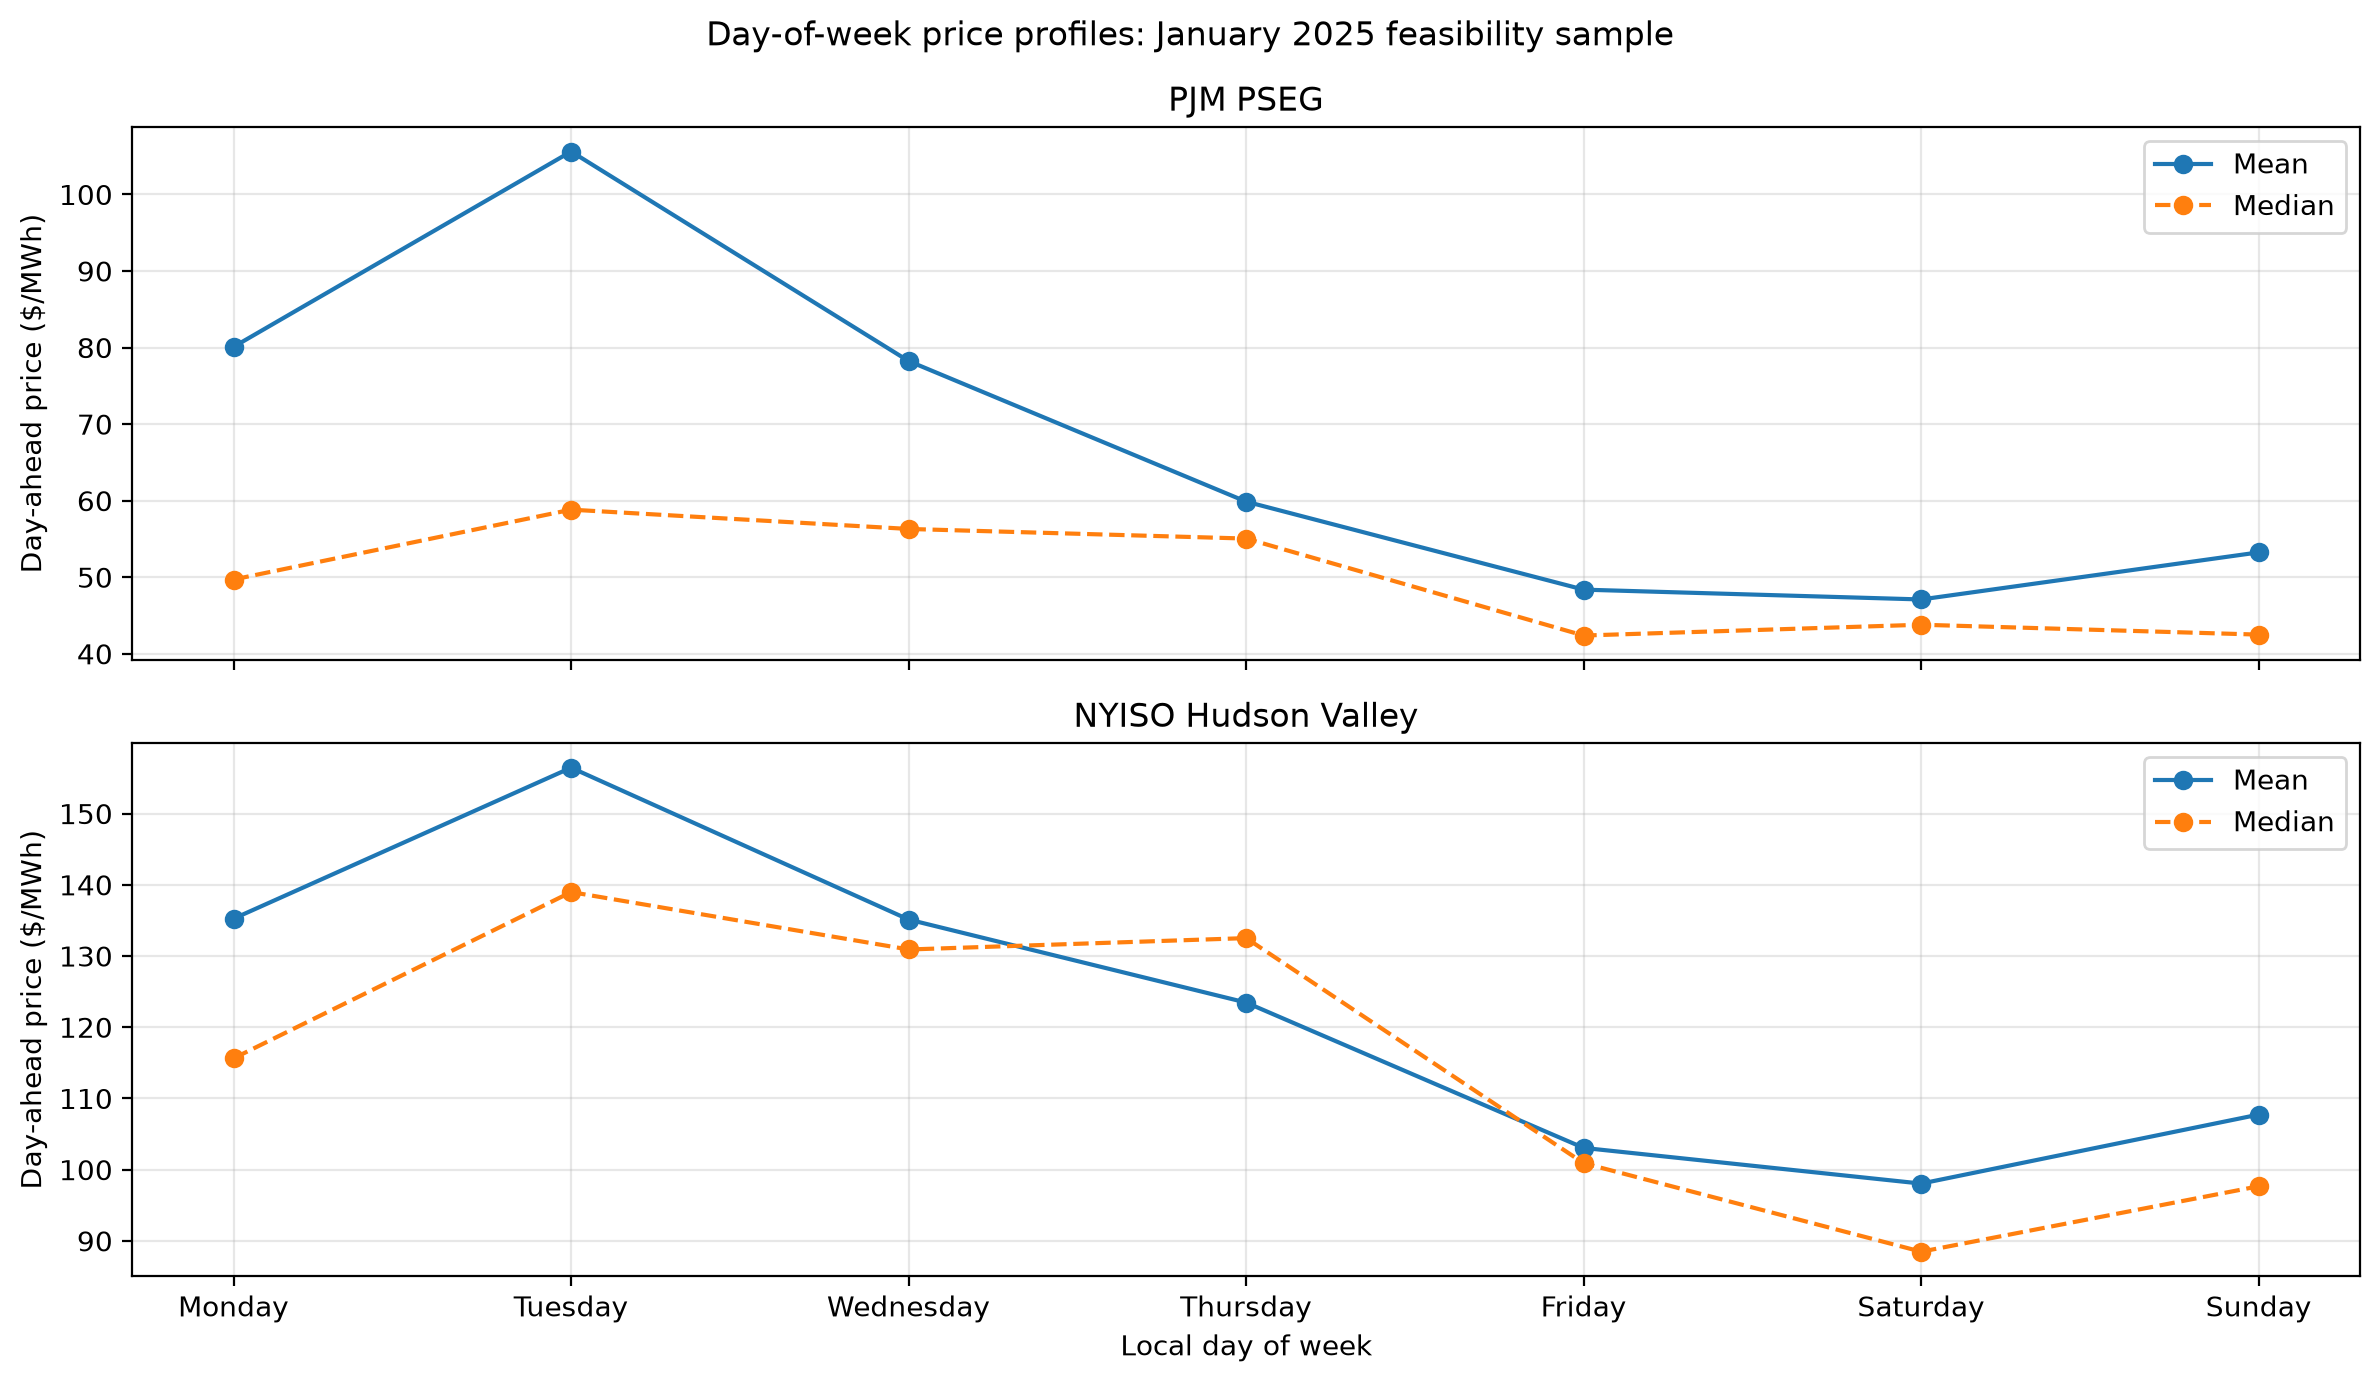

In [14]:
# .dt.day_name() derives the local weekday, and groupby(...) 
# is the same idea as SQL GROUP BY DATENAME(WEEKDAY, timestamp_local).

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

weekday_price_profiles = {}

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 7),
    sharex=True,
)

for axis, (market, data) in zip(
    axes,
    market_data.items(),
    strict=True,
):
    profile = (
        data.assign(
            day_name=data["timestamp_local"].dt.day_name()
        )
        .groupby("day_name")["day_ahead_price_usd_mwh"]
        .agg(["mean", "median"])
        .reindex(weekday_order)
    )

    weekday_price_profiles[market] = profile

    axis.plot(
        profile.index,
        profile["mean"],
        marker="o",
        label="Mean",
    )
    axis.plot(
        profile.index,
        profile["median"],
        marker="o",
        linestyle="--",
        label="Median",
    )
    axis.set_title(market)
    axis.set_ylabel("Day-ahead price ($/MWh)")
    axis.grid(alpha=0.3)
    axis.legend()

axes[-1].set_xlabel("Local day of week")
fig.suptitle("Day-of-week price profiles: January 2025 feasibility sample")
fig.tight_layout()
plt.show()

In [15]:
# The weekday/weekend pattern is visible:
# Tuesday is the highest-price day in both markets.
# Saturday is the lowest-price day in both markets.
# Friday through Sunday are generally lower than Monday through Thursday.
# PJM’s Tuesday mean is much higher than its median, again showing that 
# high-price hours influence the average.

#neither market had a negative day-ahead price in January 2025. 
# That is a finding about this feasibility month only; the project must still 
# retain negative prices if they occur later.

negative_price_hours = pd.concat(
    [
        data.loc[
            :,
            [
                "timestamp_local",
                "timestamp_utc",
                "day_ahead_price_usd_mwh",
            ],
        ].assign(analysis_market=market)
        for market, data in market_data.items()
    ],
    ignore_index=True,
)

negative_price_hours = (
    negative_price_hours.loc[
        negative_price_hours["day_ahead_price_usd_mwh"] < 0
    ]
    .sort_values(
        ["analysis_market", "timestamp_utc"]
    )
    .reset_index(drop=True)
)

print("Negative-price hours:", len(negative_price_hours))
negative_price_hours


Negative-price hours: 0


,timestamp_local,timestamp_utc,day_ahead_price_usd_mwh,analysis_market


In [16]:
# the 95th percentile is the price at or below which 95% of that market’s January hours 
# fall—similar to SQL PERCENTILE_CONT(0.95). It flags the upper tail for inspection; 
# it does not label values as errors or remove them.

high_price_thresholds = {
    market: data["day_ahead_price_usd_mwh"].quantile(0.95)
    for market, data in market_data.items()
}

high_price_hours = pd.concat(
    [
        data.loc[
            data["day_ahead_price_usd_mwh"].ge(
                high_price_thresholds[market]
            ),
            [
                "timestamp_local",
                "timestamp_utc",
                "day_ahead_price_usd_mwh",
            ],
        ].assign(
            analysis_market=market,
            high_price_threshold=high_price_thresholds[market],
        )
        for market, data in market_data.items()
    ],
    ignore_index=True,
).sort_values(
    ["analysis_market", "timestamp_utc"]
).reset_index(drop=True)

high_price_summary = pd.DataFrame(
    {
        "threshold_usd_mwh": high_price_thresholds,
        "high_price_hours": high_price_hours.groupby(
            "analysis_market"
        ).size(),
    }
)

display(high_price_summary.round(2))
high_price_hours

,threshold_usd_mwh,high_price_hours
NYISO Hudson Valley,234.53,38
PJM PSEG,198.64,38


,timestamp_local,timestamp_utc,day_ahead_price_usd_mwh,analysis_market,high_price_threshold
0,2025-01-19 17:00:00-05:00,2025-01-19 22:00:00+00:00,244.200000,NYISO Hudson Valley,234.528500
1,2025-01-20 06:00:00-05:00,2025-01-20 11:00:00+00:00,239.470000,NYISO Hudson Valley,234.528500
2,2025-01-20 07:00:00-05:00,2025-01-20 12:00:00+00:00,262.650000,NYISO Hudson Valley,234.528500
3,2025-01-20 08:00:00-05:00,2025-01-20 13:00:00+00:00,235.620000,NYISO Hudson Valley,234.528500
4,2025-01-20 09:00:00-05:00,2025-01-20 14:00:00+00:00,241.310000,NYISO Hudson Valley,234.528500
...,...,...,...,...,...
71,2025-01-22 07:00:00-05:00,2025-01-22 12:00:00+00:00,302.559852,PJM PSEG,198.639032
72,2025-01-22 08:00:00-05:00,2025-01-22 13:00:00+00:00,253.739502,PJM PSEG,198.639032
73,2025-01-22 09:00:00-05:00,2025-01-22 14:00:00+00:00,221.836427,PJM PSEG,198.639032
74,2025-01-22 18:00:00-05:00,2025-01-22 23:00:00+00:00,213.959452,PJM PSEG,198.639032


## January 2025 descriptive findings and limitations

### Findings

- Both processed market tables contain 744 unique, chronologically ordered January target hours with nonmissing day-ahead prices and actual-load values.
- NYISO Hudson Valley had a higher January mean and median day-ahead price than PJM PSEG. Both markets had right-skewed price distributions with high-price episodes.
- Both markets showed morning and evening hourly price peaks, with higher weekday than weekend prices in this January sample.
- No negative day-ahead price hours occurred in either market during January 2025.
- Using each market's 95th percentile as a descriptive high-price threshold identified 38 high-price hours in PJM PSEG at or above $234.53/MWh and 38 in NYISO Hudson Valley at or above $198.64/MWh.
- Same-hour actual load had a positive descriptive correlation with day-ahead price: 0.579 in PJM PSEG and 0.713 in NYISO Hudson Valley.
- Same-hour observed temperature had a negative descriptive correlation with day-ahead price: -0.685 in PJM PSEG and -0.678 in NYISO Hudson Valley.

### Limitations

- January 2025 is a one-month feasibility sample, not the final 2020–2024 study period. These results do not support final claims about long-run market behavior or relative predictability.
- Correlation describes association, not causation. Price, load, temperature, calendar effects, and market conditions may move together for multiple reasons.
- Same-hour actual load and observed target-hour weather are descriptive EDA fields only. They are excluded from operational day-ahead predictors because they are not known at the prediction cutoff.
- The NYISO load-forecast availability timestamp remains a ZIP-entry last-modified-time proxy, and the PJM cutoff assumptions remain provisional.